In [3]:
%pip install numpy

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl (5.3 MB)
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json 
from matplotlib_venn import venn2

fsize = 20
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

In [50]:
def load_human_evidence(fn):
    # we only want derived since we're going to compare gene ids
    df = pd.read_json(fn)
    derived_df = df['derived'].apply(pd.Series)
    return derived_df

def load_deg_evidence(fn):
    df = pd.read_json(fn)
    df = df.apply(pd.Series)
    return df

In [51]:
fn_human = "../../data/adipose_Hildreth2021/evidence_human/evidence.json"
fn_deg = "../../data/adipose_Hildreth2021/evidence_deg/evidence_unfiltered.json"

derived_human_ev = load_human_evidence(fn_human)
deg_ev = load_deg_evidence(fn_deg)

deg_ev

,cell_type_label,gene,organism,cell_source,cell_state
0,ASPC,CXCL14,homo_sapiens,adipose,NaN
1,ASPC,NEGR1,homo_sapiens,adipose,NaN
2,ASPC,DCN,homo_sapiens,adipose,NaN
3,ASPC,LAMA2,homo_sapiens,adipose,NaN
4,ASPC,APOD,homo_sapiens,adipose,NaN
...,...,...,...,...,...
17356,neutrophil,NR2C2,homo_sapiens,adipose,NaN
17357,neutrophil,HLA-B,homo_sapiens,adipose,NaN
17358,neutrophil,NAA50,homo_sapiens,adipose,NaN
17359,neutrophil,CHIC2,homo_sapiens,adipose,NaN


## Set Operations

In [52]:
def set_itx(a, b):
    return np.intersect1d(a, b).shape[0]
def set_itx_vals(a,b):
    return np.intersect1d(a,b)
def set_diff(a, b):
    return set_diff_vals(a,b).shape[0]
def set_diff_vals(a,b):
    return np.setdiff1d(a,b)
def create_venn(left, right, itx, set_a_name = "Set A", set_b_name = "Set B"):
    venn2(subsets = (left, right, itx), set_labels = (set_a_name, set_b_name))
    plt.show()

## Global Gene Comparison

In [ ]:
feature = "gene_id"

first = derived_human_ev[feature].str.strip().str.upper().unique()
second = deg_ev[feature].str.strip().str.upper().unique()

left  = set_diff(first, second)
itx   = set_itx(first, second)
right = set_diff(second, first)
itx_vals = set_itx_vals(first, second)

In [ ]:
print(left, itx, right, itx_vals)
create_venn(left, right, itx, f'Gene Evidence Human: {left}', f'Gene Evidence Deg: {right}')

## Global Celltype Comparison

In [53]:
def get_standard_labels(labels):
    """
    Returns the standardized labels of cell type labels using a global map
    """

    with open('cell_type_label_map.json', 'r') as file:
        map_dict = json.load(file)
        corrected_labels = []
        for l in list(map(str.upper,labels)):
            added = False
            for key, vals in map_dict.items():
                if l in vals or l == key:
                    corrected_labels.append(key)
                    added = True
            if not added:
                corrected_labels.append(l)
    return np.array(corrected_labels)


In [54]:
feature = "cell_type_label" # eventually change this to comparing based on a map we can create

first = derived_human_ev[feature].str.strip().str.upper().unique()
first = get_standard_labels(first)
second = deg_ev[feature].str.strip().str.upper().unique()
second = get_standard_labels(second)

left  = set_diff(first, second)
left_vals = set_diff_vals(first, second)

itx   = set_itx(first, second)
itx_vals = set_itx_vals(first, second)

right = set_diff(second, first)
right_vals = set_diff_vals(second, first)

print(left, left_vals)
print(itx, itx_vals)
print(right, right_vals)

1 ['INNATE LYMPHOID CELLS']
9 ['ADIPOCYTE' 'DENDRITIC CELL' 'ENDOTHELIUM' 'MACROPHAGE' 'MONOCYTE'
 'NATURAL KILLER CELL' 'NEUTROPHIL' 'SMOOTH MUSCLE CELLS' 'T CELL']
7 ['B CELL' 'ENDOMETRIUM' 'HUMAN ASPCS' 'LEC' 'MAST_CELL' 'MESOTHELIUM'
 'PERICYTE']


1 9 7 ['ADIPOCYTE' 'DENDRITIC CELL' 'ENDOTHELIUM' 'MACROPHAGE' 'MONOCYTE'
 'NATURAL KILLER CELL' 'NEUTROPHIL' 'SMOOTH MUSCLE CELLS' 'T CELL']


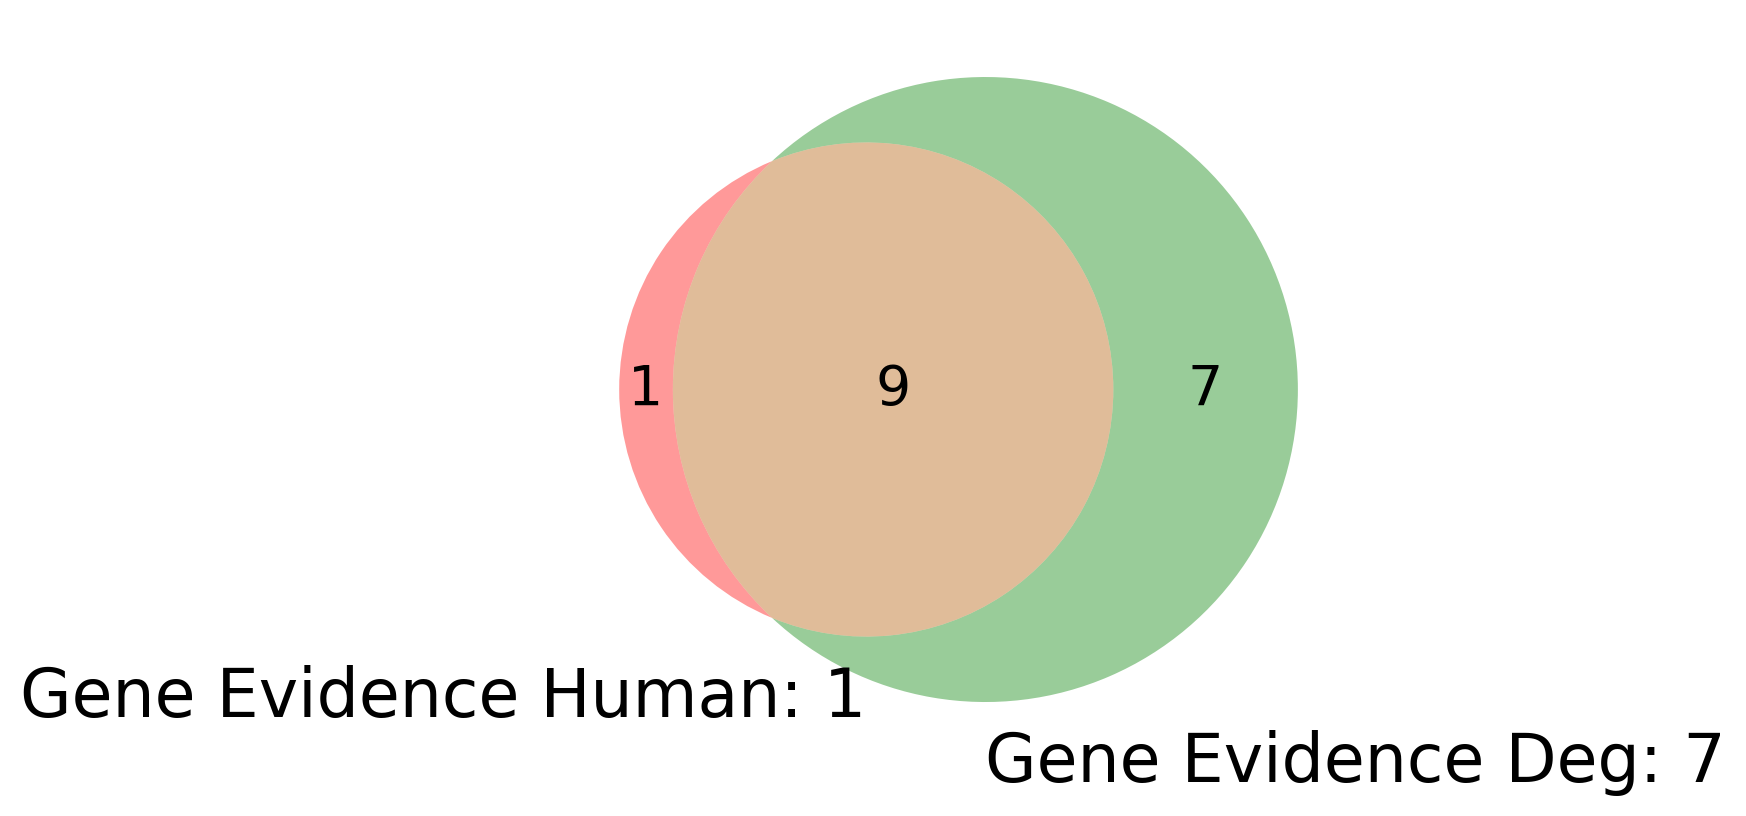

In [55]:
print(left, itx, right, itx_vals)
create_venn(left, right, itx, f'Gene Evidence Human: {left}', f'Gene Evidence Deg: {right}')

## Set Difference + Intersection of Gene Expression Between All Cells in Evidence Deg and Evidence Human

In [23]:
def make_3d_matrix(human_fn, deg_fn):
    """
    Finds similarites in gene expression between all cells mentioned in evidence deg and evidence human and returns a 3D matrix describing the left difference, intersection, and right difference in gene expression.

    Returns:
        pd.DataFrame: the 3D matrix describing set difference and intersection in gene expression
    """

    human_ev = load_human_evidence(human_fn) # gets only the derived part of evidence.json in evidence_human
    deg_ev = load_deg_evidence(deg_fn) 

    feature = "cell_type_label"

    # x axis is human evidence and y axis is deg evidence

    x_labels = sorted(human_ev[feature].unique())
    y_labels = sorted(deg_ev[feature].unique())

    result_df = pd.DataFrame(index = x_labels, columns=y_labels, dtype=object)

    for x in x_labels:
        for y in y_labels:
            genes1 = set(human_ev[human_ev[feature] == x]['gene_id'])
            genes2 = set(deg_ev[deg_ev[feature] == y]['gene_id'])

            left_diff = genes1 - genes2
            intersection = genes1 & genes2
            right_diff = genes2 - genes1

            result_df.loc[x,y] = [left_diff, intersection, right_diff]

    return result_df

In [ ]:
matrix = make_3d_matrix(fn_human, fn_deg)

matrix

## Find Cells with Similar Expression

In [25]:
def find_similar_cells():
    """
    Goes through the matrix and counts the number of intersected genes to be able to easily identify similar cells

    Returns:
        pd.DataFrame: the 3D matrix describing the count in gene expression intersection
    """
    
    intersection_df = matrix.copy()
    for index in matrix.index:
        for value in matrix.columns:
            intersection = matrix.loc[index, value][1]

            count = len(intersection)

            intersection_df.loc[index, value] = count if count > 0 else None
    
    return intersection_df


In [ ]:
cell_similarity_matrix = find_similar_cells()

cell_similarity_matrix

In [27]:
def get_similar_cells():
    result = []
    for index in cell_similarity_matrix.index:
        for value in cell_similarity_matrix.columns:
            if cell_similarity_matrix.loc[index, value]:
                result.append([index, value])
    return result


In [ ]:
get_similar_cells()